# AI Fragrance Intelligence : analyse des données et des erreurs

Ce notebook répond à trois questions qu'un lecteur exigeant se poserait avant de faire confiance au modèle :

1. **À quoi ressemblent les données ?** Combien de molécules par famille, quelles familles vont ensemble, combien d'informations manquent.
2. **Où et pourquoi le modèle se trompe-t-il ?** Familles rares, confusions fréquentes, petites molécules, molécules éloignées de l'entraînement.
3. **Le score annoncé est-il solide ?** Marge d'erreur sur le macro-F1 et comparaison statistique avec la référence publiée et avec la forêt aléatoire.

Toutes les analyses portent sur le modèle déployé (XGBoost, labels manquants ignorés). Le jeu de test n'a servi ni à entraîner ni à choisir ce modèle.

In [1]:
import json  # Lecture et écriture des résultats.
import sys  # Accès au chemin d'import.
from pathlib import Path  # Chemins de fichiers.

import joblib  # Chargement du modèle déployé.
import matplotlib.pyplot as plt  # Graphiques.
import numpy as np  # Calcul numérique.
import pandas as pd  # Tableaux de données.
from rdkit import Chem  # Lecture des molécules.

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()  # Racine du projet, d'où que l'on lance le notebook.
sys.path.insert(0, str(ROOT / "src"))  # Rend le package fragrance_ai importable.

from fragrance_ai import config  # Chemins et noms des familles.
from fragrance_ai.data import apply_policy  # Stratégies de labels manquants.
from fragrance_ai.domain import ApplicabilityDomain  # Similarité avec les molécules d'entraînement.
from fragrance_ai.evaluate import tune_thresholds  # Réglage des seuils.
from fragrance_ai.models import MultiLabelModel  # Forêt aléatoire, pour la comparaison.
from fragrance_ai.train import load_features  # Données et variables, avec cache.

L = config.LABEL_COLUMNS  # Les 12 familles, dans l'ordre du modèle.
NOMS = [config.LABELS_FR[l] for l in L]  # Leurs noms en français.
PRUNE, ROSE, ENCRE = "#A0446B", "#D8C0CC", "#2E1F2B"  # Palette de l'application.
FIG = config.REPORTS_DIR / "figures"  # Dossier des figures, reprises dans le README.
FIG.mkdir(parents=True, exist_ok=True)  # Création si besoin.
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})  # Style sobre.

X_train, df_train = load_features("train")  # 6 224 molécules d'entraînement.
X_val, df_val = load_features("val")  # 1 778 molécules de validation.
X_test, df_test = load_features("test")  # 890 molécules de test.
Y_test = df_test[L].to_numpy(dtype=int)  # Vrais labels du test.
print(len(df_train), len(df_val), len(df_test))  # Vérification des tailles.

6224 1778 890


## 1. Les données

### Familles fréquentes et rares, et labels manquants

Le premier graphique compte, pour chaque famille, les molécules d'entraînement qui en font partie (en prune) et celles pour lesquelles l'information manque (en rose).

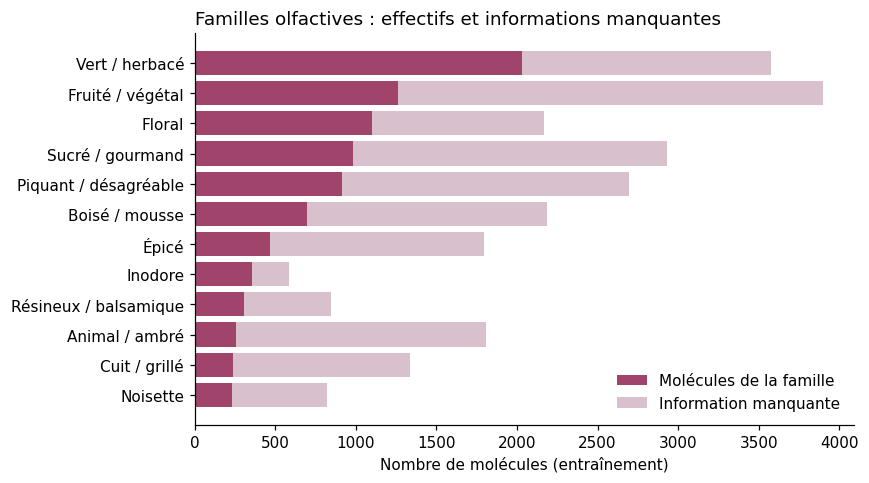

Cellules vides : 21% du total
Fruité / végétal         42.0
Sucré / gourmand         31.0
Piquant / désagréable    29.0
Animal / ambré           25.0
Vert / herbacé           25.0
Boisé / mousse           24.0
Épicé                    21.0
Cuit / grillé            18.0
Floral                   17.0
Noisette                  9.0
Résineux / balsamique     9.0
Inodore                   4.0


In [2]:
train = df_train[L]  # Labels d'entraînement (0, 1 ou vide).
pos = (train == 1).sum()  # Nombre de molécules positives par famille.
nan = train.isna().sum()  # Nombre de cellules vides par famille.
order = pos.sort_values().index  # Familles de la plus rare à la plus fréquente.

fig, ax = plt.subplots(figsize=(8, 4.5))  # Figure horizontale.
y = np.arange(len(order))  # Une ligne par famille.
ax.barh(y, pos[order], color=PRUNE, label="Molécules de la famille")  # Positifs.
ax.barh(y, nan[order], left=pos[order], color=ROSE, label="Information manquante")  # Vides, empilés à droite.
ax.set_yticks(y, [config.LABELS_FR[l] for l in order])  # Noms en français.
ax.set_xlabel("Nombre de molécules (entraînement)")  # Axe horizontal.
ax.legend(frameon=False, loc="lower right")  # Légende discrète.
ax.set_title("Familles olfactives : effectifs et informations manquantes", loc="left")  # Titre.
fig.tight_layout(); fig.savefig(FIG / "familles.png"); plt.show()  # Sauvegarde et affichage.

print(f"Cellules vides : {train.isna().mean().mean():.0%} du total")  # Part globale de vides.
print((train.isna().mean() * 100).round(0).sort_values(ascending=False).rename(index=config.LABELS_FR).to_string())  # Détail par famille.

Le déséquilibre est fort : « vert / herbacé » compte près de neuf fois plus de molécules que « noisette ». Les informations manquantes représentent environ une cellule sur cinq (21 %), et jusqu'à 42 % pour « fruité / végétal ». C'est ce qui justifie la stratégie « drop » : remplacer ces vides par 0 ou par 1 reviendrait à inventer des milliers de labels.

### Combien de familles par molécule ?

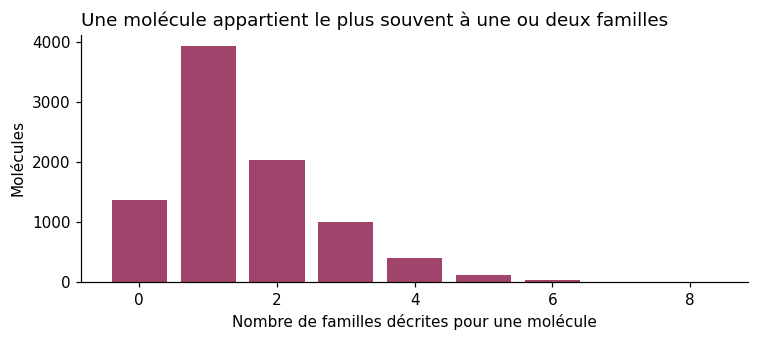

0    1374
1    3918
2    2039
3     998
4     410
5     113
6      34
7       5
8       1


In [3]:
full = pd.concat([df_train, df_val, df_test])[L].fillna(0)  # Les trois jeux, vides comptés comme absents (pour ce comptage seulement).
counts = full.sum(axis=1).astype(int).value_counts().sort_index()  # Nombre de molécules par nombre de familles.

fig, ax = plt.subplots(figsize=(7, 3.2))  # Petite figure.
ax.bar(counts.index, counts.values, color=PRUNE)  # Une barre par nombre de familles.
ax.set_xlabel("Nombre de familles décrites pour une molécule"); ax.set_ylabel("Molécules")  # Axes.
ax.set_title("Une molécule appartient le plus souvent à une ou deux familles", loc="left")  # Titre.
fig.tight_layout(); fig.savefig(FIG / "familles_par_molecule.png"); plt.show()  # Sauvegarde et affichage.
print(counts.to_string())  # Valeurs exactes.

La plupart des molécules ont une ou deux familles, mais certaines en cumulent jusqu'à huit. On est bien dans un problème **multi-label** : chaque famille se prédit indépendamment, et une molécule peut en avoir plusieurs. Les 1 374 molécules sans aucune famille ne sont pas forcément inodores : leurs descriptions étaient souvent trop vagues pour être classées.

### Quelles familles vont ensemble ?

La carte ci-dessous se lit ligne par ligne : parmi les molécules de la famille en ligne, quelle part appartient aussi à la famille en colonne ?

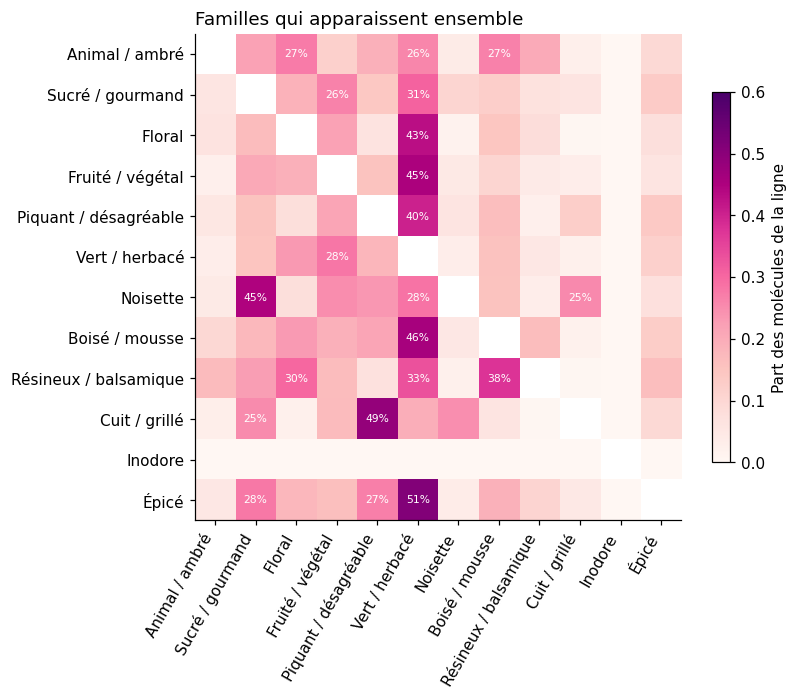

In [4]:
obs = df_train[L].fillna(0).to_numpy()  # Labels d'entraînement, vides comptés comme absents.
co = (obs.T @ obs) / np.maximum(obs.sum(axis=0)[:, None], 1)  # P(colonne | ligne).
np.fill_diagonal(co, np.nan)  # La diagonale (100 %) n'apporte rien.

fig, ax = plt.subplots(figsize=(7.5, 6.5))  # Figure carrée.
im = ax.imshow(co, cmap="RdPu", vmin=0, vmax=0.6)  # Carte de chaleur dans les tons de l'application.
ax.set_xticks(range(12), NOMS, rotation=60, ha="right"); ax.set_yticks(range(12), NOMS)  # Noms des familles.
for i in range(12):  # Valeurs écrites dans les cases…
    for j in range(12):
        if i != j and co[i, j] >= 0.25:  # …seulement les associations marquées, pour rester lisible.
            ax.text(j, i, f"{co[i, j]:.0%}", ha="center", va="center", fontsize=7, color="white")
fig.colorbar(im, ax=ax, shrink=0.7, label="Part des molécules de la ligne")  # Échelle.
ax.set_title("Familles qui apparaissent ensemble", loc="left")  # Titre.
fig.tight_layout(); fig.savefig(FIG / "cooccurrences.png"); plt.show()  # Sauvegarde et affichage.

« Vert / herbacé » est la famille « carrefour » : selon la famille, entre un cinquième et la moitié des molécules sont aussi décrites comme vertes (51 % des molécules épicées, par exemple). Seules les molécules inodores y échappent, logiquement. On le retrouvera dans les erreurs du modèle.

## 2. Où le modèle se trompe-t-il ?

On charge le modèle déployé et ses seuils, puis on calcule ses décisions sur le test.

In [5]:
model = joblib.load(config.MODEL_PATH)  # Modèle déployé (XGBoost).
meta = json.loads(config.METADATA_PATH.read_text())  # Ses seuils et ses scores.
thresholds = np.array([meta["thresholds"][l] for l in L])  # Un seuil par famille.
P_test = model.predict_proba(X_test)  # Probabilités sur le test.
Yp_test = (P_test >= thresholds).astype(int)  # Décisions : famille retenue ou non.


def macro_f1(y_true, y_pred):
    """Macro-F1 calculé directement (rapide pour le bootstrap), en ignorant les familles absentes de l'échantillon."""
    tp = (y_true & y_pred).sum(0)  # Vrais positifs par famille.
    fp = ((1 - y_true) & y_pred).sum(0)  # Faux positifs.
    fn = (y_true & (1 - y_pred)).sum(0)  # Faux négatifs.
    denom = 2 * tp + fp + fn  # Dénominateur du F1.
    return float(np.mean(2 * tp[denom > 0] / denom[denom > 0]))  # Moyenne sur les familles présentes.


print(f"Macro-F1 test : {macro_f1(Y_test, Yp_test):.3f}")  # Doit redonner 0,468.

Macro-F1 test : 0.468


### Les familles rares sont les plus difficiles

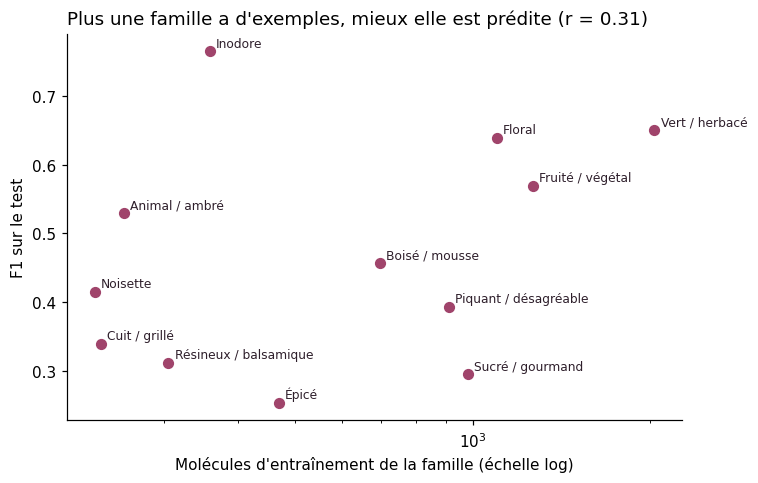

In [6]:
per_f1 = np.array([meta["test_metrics"]["per_label"][l]["f1"] for l in L])  # F1 par famille.
prevalence = (df_train[L] == 1).sum().to_numpy()  # Exemples d'entraînement par famille.
r = np.corrcoef(np.log(prevalence), per_f1)[0, 1]  # Corrélation (échelle logarithmique des effectifs).

fig, ax = plt.subplots(figsize=(7, 4.5))  # Nuage de points.
ax.scatter(prevalence, per_f1, color=PRUNE, s=40)  # Une famille = un point.
for x, yv, nom in zip(prevalence, per_f1, NOMS):  # Nom de chaque famille à côté de son point.
    ax.annotate(nom, (x, yv), xytext=(4, 3), textcoords="offset points", fontsize=8, color=ENCRE)
ax.set_xscale("log"); ax.set_xlabel("Molécules d'entraînement de la famille (échelle log)"); ax.set_ylabel("F1 sur le test")  # Axes.
ax.set_title(f"Plus une famille a d'exemples, mieux elle est prédite (r = {r:.2f})", loc="left")  # Titre avec la corrélation.
fig.tight_layout(); fig.savefig(FIG / "f1_vs_effectif.png"); plt.show()  # Sauvegarde et affichage.

La relation est nette, avec une exception parlante : « inodore » est rare mais très bien prédit (F1 ≈ 0,77), probablement parce que ces molécules partagent des caractéristiques physiques simples (grosses, peu volatiles). À l'inverse, « épicé » et « sucré / gourmand » restent faibles malgré des effectifs moyens : ce sont des familles plus subjectives, définies par l'usage culinaire autant que par la chimie.

### Avec quoi le modèle confond-il chaque famille ?

Pour chaque famille, on regarde les **faux positifs** (le modèle annonce la famille à tort) et la famille réellement présente le plus souvent dans ces cas-là.

In [7]:
rows = []  # Une ligne par famille.
for j, l in enumerate(L):  # Pour chaque famille…
    fp = (Yp_test[:, j] == 1) & (Y_test[:, j] == 0)  # …ses faux positifs…
    fn = (Yp_test[:, j] == 0) & (Y_test[:, j] == 1)  # …ses faux négatifs…
    present = Y_test[fp].sum(axis=0); present[j] = 0  # …et les familles réellement présentes lors des faux positifs.
    k = int(present.argmax())  # La plus fréquente.
    rows.append({"Famille": NOMS[j], "Faux positifs": int(fp.sum()), "Faux négatifs": int(fn.sum()),
                 "Souvent confondue avec": NOMS[k], "Part": f"{present[k] / max(fp.sum(), 1):.0%}"})
confusions = pd.DataFrame(rows).sort_values("Faux positifs", ascending=False)  # Tableau trié.
confusions

,Famille,Faux positifs,Faux négatifs,Souvent confondue avec,Part
5,Vert / herbacé,186,44,Floral,33%
1,Sucré / gourmand,121,66,Vert / herbacé,41%
3,Fruité / végétal,97,51,Vert / herbacé,46%
2,Floral,97,46,Vert / herbacé,45%
7,Boisé / mousse,94,65,Vert / herbacé,44%
11,Épicé,88,42,Vert / herbacé,48%
8,Résineux / balsamique,82,42,Vert / herbacé,44%
10,Inodore,56,92,Piquant / désagréable,27%
4,Piquant / désagréable,53,86,Inodore,40%
9,Cuit / grillé,27,12,Fruité / végétal,33%


Deux enseignements :

- **« Vert / herbacé » est la principale source de confusion.** C'est la famille la plus fréquente, et elle accompagne beaucoup d'autres : le modèle l'ajoute volontiers (186 faux positifs), et quand il annonce à tort une autre famille, la molécule était souvent « verte ».
- **« Inodore » et « piquant / désagréable » se confondent entre eux.** Ce sont souvent de petites molécules, dont l'odeur dépend de détails (volatilité, seuil de perception) que les fingerprints captent mal.

### La taille des molécules compte

In [8]:
size = np.array([Chem.MolFromSmiles(s).GetNumHeavyAtoms() for s in df_test[config.SMILES_COL]])  # Atomes lourds (hors hydrogènes).
bins = [(0, 10, "moins de 10"), (10, 14, "10 à 13"), (14, 999, "14 et plus")]  # Classes de taille.
size_rows = []  # Résultats par classe.
for lo, hi, nom in bins:  # Pour chaque classe…
    k = (size >= lo) & (size < hi)  # …les molécules concernées…
    size_rows.append({"Taille (atomes lourds)": nom, "Molécules": int(k.sum()), "Macro-F1": round(macro_f1(Y_test[k], Yp_test[k]), 3)})
pd.DataFrame(size_rows)  # …et leur score.

,Taille (atomes lourds),Molécules,Macro-F1
0,moins de 10,90,0.290
1,10 à 13,268,0.468
2,14 et plus,532,0.393


Le modèle est le plus à l'aise avec les molécules de taille intermédiaire (10 à 13 atomes lourds), typiques des matières premières de parfumerie. Sous 10 atomes, le macro-F1 tombe autour de 0,29 : une petite molécule allume peu de motifs dans son empreinte, alors que de minuscules différences de structure y changent beaucoup l'odeur (penser aux thiols ou aux acides courts). Les plus grosses molécules (14 atomes et plus) sont aussi moins bien prédites (0,39) : leurs nombreux motifs brouillent davantage le signal.

### La similarité avec l'entraînement prédit-elle la qualité ?

L'application affiche, pour chaque molécule, sa similarité avec la molécule d'entraînement la plus proche. On vérifie ici si cet indicateur tient ses promesses sur le test.

In [9]:
domain = ApplicabilityDomain()  # Référence d'entraînement.
sims = np.array([domain.nearest(s)["similarity"] for s in df_test[config.SMILES_COL]])  # Similarité de chaque molécule de test.
rng = np.random.default_rng(0)  # Graine pour des intervalles reproductibles.
sim_rows = []  # Résultats par niveau de similarité.
for lo, hi, nom in [(0, 0.4, "faible (< 0,4)"), (0.4, 0.6, "moyenne (0,4 à 0,6)"), (0.6, 1.01, "élevée (≥ 0,6)")]:
    idx = np.where((sims >= lo) & (sims < hi))[0]  # Molécules du niveau.
    boot = [macro_f1(Y_test[i], Yp_test[i]) for i in (rng.choice(idx, len(idx)) for _ in range(500))]  # Bootstrap.
    lo95, hi95 = np.percentile(boot, [2.5, 97.5])  # Intervalle de confiance à 95 %.
    sim_rows.append({"Similarité": nom, "Molécules": len(idx), "Macro-F1": round(macro_f1(Y_test[idx], Yp_test[idx]), 3),
                     "Intervalle 95 %": f"{lo95:.2f} – {hi95:.2f}"})
pd.DataFrame(sim_rows)  # Tableau.

,Similarité,Molécules,Macro-F1,Intervalle 95 %
0,"faible (< 0,4)",225,0.420,0.33 – 0.48
1,"moyenne (0,4 à 0,6)",328,0.443,0.40 – 0.48
2,"élevée (≥ 0,6)",337,0.480,0.42 – 0.53


Le score monte bien avec la similarité (de 0,42 à 0,48), mais **l'effet est modeste et les intervalles se chevauchent**. Sur ces données, l'indicateur de similarité donne une tendance utile, pas une garantie. C'est pour cela que l'application le présente comme un repère indicatif, et que ses seuils (0,4 et 0,6) sont des conventions de chimie computationnelle et non des frontières mesurées ici. Un résultat honnête vaut mieux qu'une fonctionnalité qui surpromet.

## 3. Le score est-il solide ?

### Marge d'erreur du macro-F1

Le test ne contient que 890 molécules : avec d'autres molécules, le score aurait été un peu différent. Le **bootstrap** estime cette variabilité. On tire 2 000 fois, avec remise, 890 molécules du test et on recalcule le score à chaque fois.

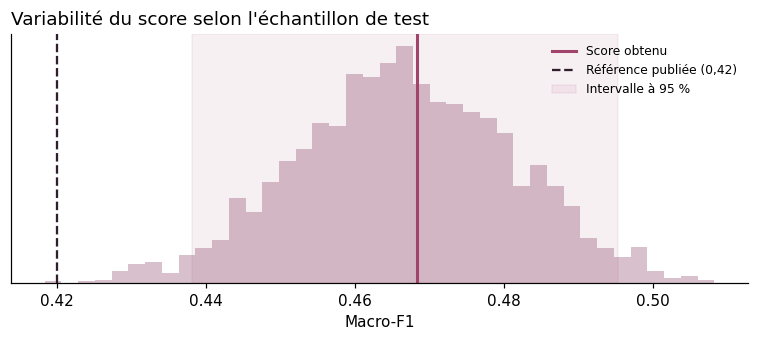

Intervalle de confiance à 95 % : 0.438 – 0.495
Part des tirages au-dessus de 0,42 : 100.0%


In [10]:
rng = np.random.default_rng(42)  # Graine fixe.
n = len(Y_test)  # 890 molécules.
boot = np.array([macro_f1(Y_test[i], Yp_test[i]) for i in (rng.integers(0, n, n) for _ in range(2000))])  # 2 000 tirages.
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])  # Intervalle de confiance à 95 %.
above = (boot > config.PAPER_BASELINE_MACRO_F1).mean()  # Part des tirages au-dessus de 0,42.

fig, ax = plt.subplots(figsize=(7, 3.2))  # Histogramme.
ax.hist(boot, bins=40, color=ROSE)  # Distribution des scores.
ax.axvline(macro_f1(Y_test, Yp_test), color=PRUNE, lw=2, label="Score obtenu")  # Score réel.
ax.axvline(config.PAPER_BASELINE_MACRO_F1, color=ENCRE, ls="--", lw=1.5, label="Référence publiée (0,42)")  # Référence.
ax.axvspan(ci_low, ci_high, color=PRUNE, alpha=0.08, label="Intervalle à 95 %")  # Intervalle.
ax.set_xlabel("Macro-F1"); ax.set_yticks([]); ax.legend(frameon=False, fontsize=8)  # Axes et légende.
ax.set_title("Variabilité du score selon l'échantillon de test", loc="left")  # Titre.
fig.tight_layout(); fig.savefig(FIG / "bootstrap.png"); plt.show()  # Sauvegarde et affichage.
print(f"Intervalle de confiance à 95 % : {ci_low:.3f} – {ci_high:.3f}")  # Résultat.
print(f"Part des tirages au-dessus de 0,42 : {above:.1%}")  # Résultat.

Tout l'intervalle de confiance se situe au-dessus de 0,42 : l'écart avec la référence publiée n'est pas un effet du hasard de l'échantillon. Une nuance reste valable : le bootstrap mesure l'incertitude due au jeu de test, pas les différences de protocole avec les auteurs (réglage des seuils, traitement des labels manquants).

### XGBoost est-il vraiment meilleur que la forêt aléatoire ?

Les deux modèles sont à 0,468 et 0,464. On réentraîne la forêt aléatoire (environ une minute) et on compare les deux sur **les mêmes** tirages bootstrap : c'est une comparaison appariée.

In [11]:
rf = MultiLabelModel("random_forest").fit(X_train, apply_policy(df_train, "drop"))  # Forêt aléatoire, même protocole.
Y_val = df_val[L].to_numpy(dtype=int)  # Labels de validation.
rf_thresholds = tune_thresholds(Y_val, rf.predict_proba(X_val))  # Ses propres seuils, réglés sur la validation.
Yp_rf = (rf.predict_proba(X_test) >= rf_thresholds).astype(int)  # Ses décisions sur le test.

rng = np.random.default_rng(42)  # Mêmes tirages pour les deux modèles.
diff = np.array([macro_f1(Y_test[i], Yp_test[i]) - macro_f1(Y_test[i], Yp_rf[i])  # Écart XGBoost − forêt…
                 for i in (rng.integers(0, n, n) for _ in range(2000))])  # …sur chaque tirage.
d_low, d_high = np.percentile(diff, [2.5, 97.5])  # Intervalle de l'écart.
print(f"Forêt aléatoire : {macro_f1(Y_test, Yp_rf):.3f}")  # Score de la forêt.
print(f"Écart XGBoost − forêt, intervalle à 95 % : {d_low:+.3f} à {d_high:+.3f}")  # L'écart contient-il 0 ?
print(f"XGBoost devant dans {(diff > 0).mean():.0%} des tirages")  # Part des tirages favorables.

Forêt aléatoire : 0.464
Écart XGBoost − forêt, intervalle à 95 % : -0.011 à +0.019
XGBoost devant dans 69% des tirages


L'intervalle de l'écart contient zéro : **XGBoost et la forêt aléatoire sont statistiquement à égalité**. Le choix de XGBoost reste justifié (meilleur sur la validation, plus léger à déployer, explications SHAP rapides), mais il serait faux de le présenter comme nettement supérieur. En revanche, l'écart avec les réseaux de neurones (0,07 point ou plus) dépasse largement cette marge d'erreur.

## Conclusions

- **Le score est solide** : macro-F1 de 0,468, intervalle à 95 % entièrement au-dessus de la référence publiée.
- **Les deux modèles à arbres se valent** ; les réseaux de neurones sont nettement derrière sur ce volume de données.
- **Les erreurs ont des causes identifiables** : familles rares, omniprésence de « vert / herbacé », molécules très petites ou très grosses, et confusion entre « inodore » et « piquant ».
- **L'indicateur de similarité est une tendance, pas une garantie.**

Pistes d'amélioration qui en découlent : pondérer davantage les familles rares, ajouter des descripteurs adaptés aux petites molécules (volatilité, groupes soufrés), et tester un GNN pré-entraîné sur de grandes bases de molécules.

In [12]:
results = {  # Chiffres clés, repris par l'application et le README.
    "macro_f1": round(macro_f1(Y_test, Yp_test), 4),  # Score du modèle déployé.
    "macro_f1_ci95": [round(ci_low, 4), round(ci_high, 4)],  # Intervalle de confiance.
    "share_above_paper": round(float(above), 4),  # Part des tirages au-dessus de 0,42.
    "xgb_minus_rf_ci95": [round(d_low, 4), round(d_high, 4)],  # Écart avec la forêt aléatoire.
    "by_similarity": sim_rows,  # Score par niveau de similarité.
    "by_size": size_rows,  # Score par taille de molécule.
}
(config.REPORTS_DIR / "analysis.json").write_text(json.dumps(results, indent=2, ensure_ascii=False))  # Sauvegarde.
results  # Affichage.

{'macro_f1': 0.4683,
 'macro_f1_ci95': [np.float64(0.4381), np.float64(0.4954)],
 'share_above_paper': 0.9995,
 'xgb_minus_rf_ci95': [np.float64(-0.0105), np.float64(0.0193)],
 'by_similarity': [{'Similarité': 'faible (< 0,4)',
   'Molécules': 225,
   'Macro-F1': 0.42,
   'Intervalle 95 %': '0.33 – 0.48'},
  {'Similarité': 'moyenne (0,4 à 0,6)',
   'Molécules': 328,
   'Macro-F1': 0.443,
   'Intervalle 95 %': '0.40 – 0.48'},
  {'Similarité': 'élevée (≥ 0,6)',
   'Molécules': 337,
   'Macro-F1': 0.48,
   'Intervalle 95 %': '0.42 – 0.53'}],
 'by_size': [{'Taille (atomes lourds)': 'moins de 10',
   'Molécules': 90,
   'Macro-F1': 0.29},
  {'Taille (atomes lourds)': '10 à 13', 'Molécules': 268, 'Macro-F1': 0.468},
  {'Taille (atomes lourds)': '14 et plus',
   'Molécules': 532,
   'Macro-F1': 0.393}]}